In [2]:
import pandas as pd
from grid_world.envGen_grid_world import GridWorld_envGen
from DMEIRL.DeepMEIRL_FC import DMEIRL
%load_ext autoreload
%autoreload 2

In [13]:
# D:\TangYe\HBTPST\wifi_track_data\dacang\imgs
from PIL import Image

# 打开原始图片
img = Image.open(r'D:\TangYe\HBTPST\wifi_track_data\dacang\imgs\roads.png')

# 使用高质量重采样方法调整尺寸
new_img = img.resize((600, 450), Image.Resampling.LANCZOS)

# 保存新图片
new_img.save(r'D:\TangYe\HBTPST\wifi_track_data\dacang\imgs\roads_600x450.png', format='PNG')



# Figure 15(a): 2D Rewards
An attempt was made to simulate the values of REWARDS using the RELU and TANH functions as output functions and to derive the simulated expert trajectories (notation)

In [164]:

env_folder_path = 'wifi_track_data/dacang/grid_data/env_imgs/40_30'
# # Cluster 0
# expert_traj_path = "wifi_track_data/dacang/cluster_data/trajs_sliced_0919_40x30_cluster0"
# model_path = r'train\0920_0\0920sliced_bias0_v0.001_tp0.8_dis0.95_lr0.0001_wd0.2_clip-1_l(60, 120, 240, 120, 60)\model_deep_irl_fc_epoch500_mse2.144083261489868_0920.pth'
#
# # Cluster 1,2
# expert_traj_path = "wifi_track_data/dacang/cluster_data/trajs_sliced_0919_40x30_cluster1_2"
# model_path = r'train\0920\0920sliced_bias0_v0.001_tp0.8_dis0.95_lr0.0001_wd0.2_clip-1_l(60, 120, 240, 120, 60)\model_deep_irl_fc_epoch500_mse1.052821159362793_0920.pth'

# all
expert_traj_path = "wifi_track_data/dacang/track_data/trajs_sliced_0919_40x30.csv"
model_path = r'train\0921\0921sliced_bias0_v0.001_tp0.8_dis0.95_lr0.0001_wd0.2_clip-1_l(60, 120, 240, 120, 60)\model_deep_irl_fc_epoch500_mse1.199437141418457_0921.pth'

# # all 2
# expert_traj_path = "wifi_track_data/dacang/track_data/trajs_sliced_0919_40x30.csv"
# model_path = r'train\0923\0923sliced_bias0_v0.001_tp0.8_dis0.95_lr0.0001_wd0.2_clip-1_l(60, 120, 240, 120, 60)\model_deep_irl_fc_epoch1000_mse1.1585525274276733_0923.pth'



world = GridWorld_envGen(
    width=40,height=30,
    envs_img_folder_path=env_folder_path,
    experts_traj_filePath=expert_traj_path,
    model_path=model_path,
    model_n_input=30,
    model_layers=(60, 120, 240, 120, 60),
    trans_prob=0.8,
    discount=0.95
)

D:\TangYe\HBTPST\grid_world\envGen_grid_world.py:46: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Get experts trajs num:7353
trajs all avg length: 23


parsing environments from folder:: 100%|██████████| 30/30 [00:06<00:00,  4.80it/s]


In [149]:

# 生成轨迹后显示
trajs = world.GenerateTrajs(traj_count=2000, avg_length=23,save=True)
world.ShowLearnedTrajs()
world.ShowExpertTrajs()

100%|██████████| 2000/2000 [00:02<00:00, 717.14it/s]


In [165]:
world.RefreshInitState()

In [163]:
world.ShowSVFOrigin()

In [ ]:
world.ShowGridWorld_Activated()

In [159]:
world.ShowGridWorld_Count_log()

In [158]:
world.GenerateTrajs(50,30,save=False)

100%|██████████| 50/50 [00:00<00:00, 2777.68it/s]


,m,trajs
0,1,"[[877, 3], [876, 3], [877, 3], [876, 0]]"
1,2,"[[420, 1], [460, 1], [500, 3], [499, 0], [500,..."
2,3,"[[743, 2], [783, 2], [783, 2], [743, 2], [703,..."
3,4,"[[788, 2], [748, 3], [747, 0], [747, 0], [747,..."
4,5,"[[832, 0], [832, 0], [832, 0], [831, 4], [832,..."
5,6,"[[743, 2], [703, 2], [663, 2], [623, 0], [623,..."
6,7,"[[832, 0], [832, 0], [832, 0], [832, 0], [832,..."
7,8,"[[743, 2], [703, 2], [663, 2], [623, 0], [622,..."
8,9,"[[832, 0], [832, 0], [832, 0], [832, 0], [832,..."
9,10,"[[879, 3], [879, 3], [878, 3], [878, 3], [877,..."


In [ ]:
world.PrintTrajs(30)

In [145]:
import pandas as pd, numpy as np
from ast import literal_eval
from utils_tool import myplot

# 配置网格尺寸
width, height = 40, 30
delta_t = 1.0  # 每步=1小时
start_hour = 0.0

# # expert_trajs
# df = pd.read_csv('wifi_track_data/dacang/track_data/trajs_sliced_0919_40x30.csv')
# learned_trajs
df = pd.read_csv('wifi_track_data/dacang/learned_trajs/learned_trajs_0921.csv')

df['trajs'] = df['trajs'].apply(lambda x: x if isinstance(x, list) else literal_eval(x))
state_to_xy = lambda s: (s % width, s // width)

def segments_from_traj(traj, delta_t=1.0):
    if not traj: return []
    states = [int(t[0]) for t in traj]
    segs = []
    cur_state, cur_dur = states[0], delta_t
    for s in states[1:]:
        if s == cur_state:
            cur_dur += delta_t
        else:
            segs.append((cur_state, cur_dur))
            cur_state, cur_dur = s, delta_t
    segs.append((cur_state, cur_dur))
    return segs

def active_moment_abs(traj, start_hour=0.0, delta_t=1.0):
    segs = segments_from_traj(traj, delta_t)
    if not segs: return start_hour
    t = 0.0; centers = []; weights = []
    for _, dur in segs:
        centers.append(t + dur/2.0)
        weights.append(dur)
        t += dur
    wmean_center = float(np.average(centers, weights=weights))
    return start_hour + wmean_center  # 绝对小时

def stats(traj):
    T = len(traj)
    if T == 0:
        return pd.Series([0.0, 0.0, 0.0, 0.0], index=['active_moment','moving_dis','middle_moment','Dur'])
    states = [t[0] for t in traj]
    xy = np.array([state_to_xy(int(s)) for s in states], dtype=float)
    moving_dis = float(np.linalg.norm(xy[1:] - xy[:-1], axis=1).sum()) if T>1 else 0.0
    Dur = max(T-1, 0) * delta_t
    middle_moment = start_hour + Dur/2.0
    active_moment = active_moment_abs(traj, start_hour=start_hour, delta_t=delta_t)
    return pd.Series([active_moment, moving_dis, middle_moment, Dur],
                     index=['active_moment','moving_dis','middle_moment','Dur'])

df_sta = df['trajs'].apply(stats)

myplot.Boxes([
    (df_sta['active_moment'],  "平均活跃时刻(小时)"),
    (df_sta['moving_dis'],     "移动距离"),
    # (df_sta['middle_moment'],  "中间时刻(小时)"),
    (df_sta['Dur'],            "持续时间(小时)"),
], box_title="轨迹特征箱线图")

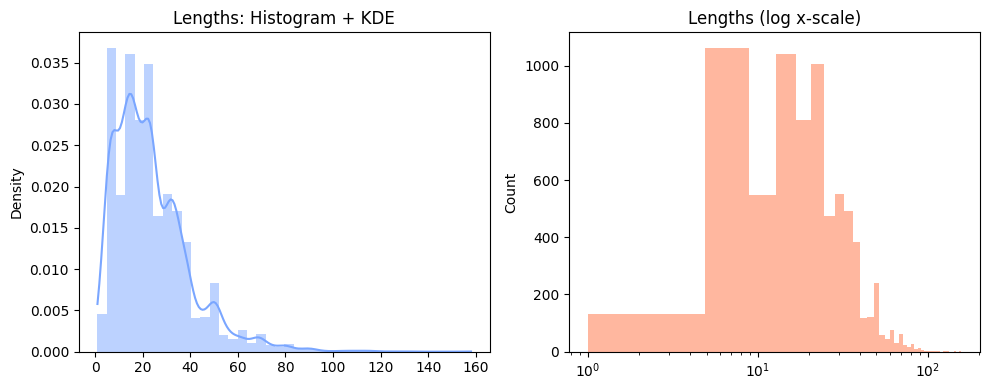

In [143]:
import pandas as pd, numpy as np
from ast import literal_eval
import matplotlib.pyplot as plt
import seaborn as sns

# 读取专家轨迹，取长度（步数）
df = pd.read_csv('wifi_track_data/dacang/track_data/trajs_sliced_0919_40x30.csv')
lengths = df['trajs'].apply(lambda s: len(literal_eval(s))).values
lengths = lengths[lengths > 0]

plt.figure(figsize=(10,4))
# 直方图 + KDE
plt.subplot(1,2,1)
sns.histplot(lengths, bins=40, stat='density', kde=True, color='#7aa6ff', edgecolor='none')
plt.title('Lengths: Histogram + KDE')

# 对数x坐标直方图（看长尾）
plt.subplot(1,2,2)
sns.histplot(lengths, bins=40, color='#ff9f7f', edgecolor='none')
plt.xscale('log')
plt.title('Lengths (log x-scale)')

plt.tight_layout()
plt.show()